# PV Tilt

Compare eddy tilt direction with planetary, topographic, and total shallow-water PV-gradient directions.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import seacofs_tilt_tools as tilt

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
#############################################
ELLIPSE_FRAC= 1
USE_PV_CACHE = True
df_eddies, _ = tilt.load_tilt_tables(paths, add_regions=True, grid=grid)
vertical = tilt.load_vert(paths)
df_eddies = tilt.add_pv_gradient_terms(
    df_eddies,
    grid,
    core_mean=True,
    frac=ELLIPSE_FRAC,
    surface_method="esp_gaussian",
    averaging="nonlinear",
    use_max_abs_w=True,
    max_depth_m=1000,
    use_cache=USE_PV_CACHE,
)
#############################################

df_eddies[["Eddy", "Day", "Cyc", "Region", "TiltDis", "TiltDir", "PV_grad_mag", "dtheta_PV_grad"]].head()


,Eddy,Day,Cyc,Region,TiltDis,TiltDir,PV_grad_mag,dtheta_PV_grad
0,1,1462,CE,D1,NaN,NaN,6.798166e-15,NaN
1,1,1463,CE,D1,NaN,NaN,3.915106e-15,NaN
2,1,1464,CE,D1,NaN,NaN,3.132720e-15,NaN
3,1,1465,CE,D1,19.823350,87.507772,8.968861e-15,63.637171
4,1,1466,CE,D1,15.055658,105.302388,1.259266e-14,100.249586


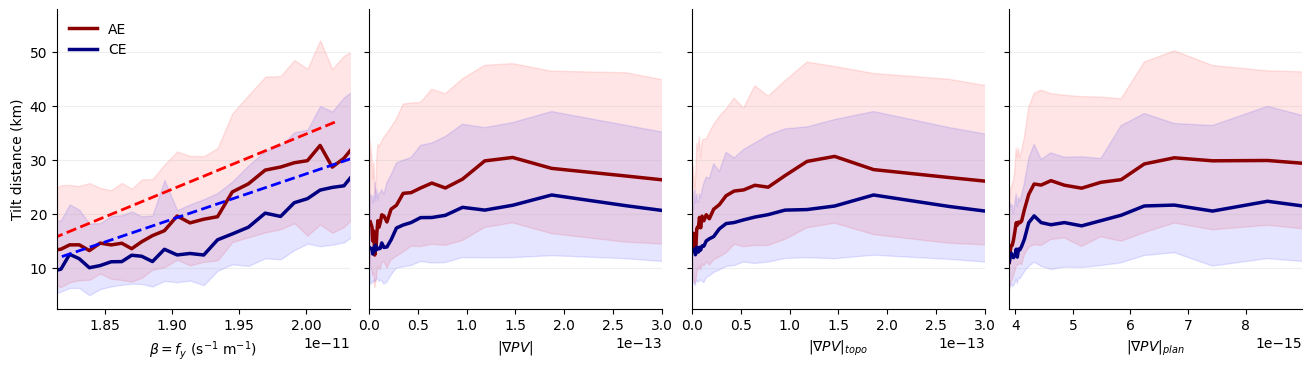

In [2]:
fig, axs = plt.subplots(1, 4, figsize=(13, 3.6), sharey=True, constrained_layout=True)

panels = [
    ("beta", r"$\beta=f_y$ (s$^{-1}$ m$^{-1}$)", None, True),
    ("PV_grad_mag", r"$|\nabla PV|$", (0, 3e-13), False),
    ("PV_grad_topo_mag", r"$|\nabla PV|_{topo}$", (0, 3e-13), False),
    ("PV_grad_plan_mag", r"$|\nabla PV|_{plan}$", None, False),
]

for ax, (col, label, xlim, linfit) in zip(axs, panels):
    tilt.binned_tilt_panel(ax, df_eddies, col, label, xlim=xlim, linfit=linfit)
axs[0].set_ylabel("Tilt distance (km)")
axs[0].legend(frameon=False)
plt.show()


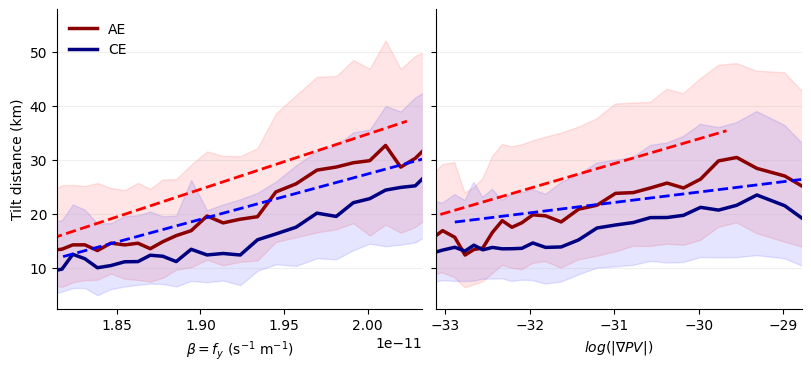

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3.6), sharey=True, constrained_layout=True)

df_eddies['log_PV_grad_mag'] = np.log(df_eddies.PV_grad_mag)

panels = [
    ("beta", r"$\beta=f_y$ (s$^{-1}$ m$^{-1}$)", None, True),
    ("log_PV_grad_mag", r"$log(|\nabla PV|)$", None, True),
]

for ax, (col, label, xlim, linfit) in zip(axs, panels):
    tilt.binned_tilt_panel(ax, df_eddies, col, label, xlim=xlim, linfit=linfit)
axs[0].set_ylabel("Tilt distance (km)")
axs[0].legend(frameon=False)
plt.show()

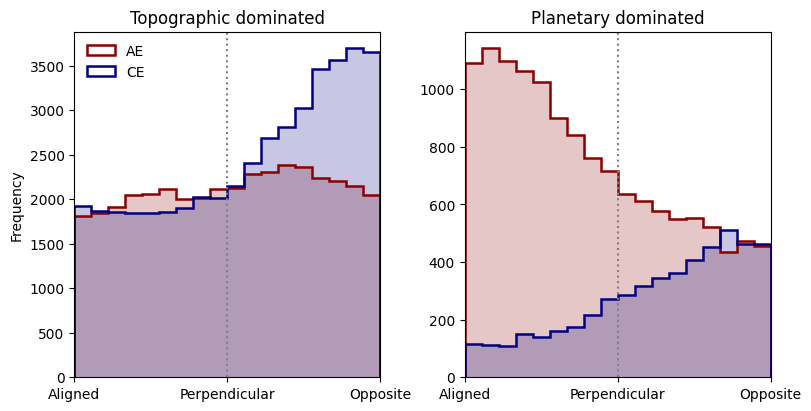

In [4]:
df_plot = df_eddies.copy()
col_filters = [
    ("Topographic dominated", df_plot.topo_plan_ratio > 0),
    ("Planetary dominated", df_plot.topo_plan_ratio < 0),
]

bins = np.arange(0, 180+10, 10)
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharex=True, constrained_layout=True)
for c, (col_label, mask) in enumerate(col_filters):
        ax = axs[c]
        col = df_plot.loc[mask]
        for cyc, color in [("AE", "darkred"), ("CE", "navy")]:
            # if cyc=='CE':
            vals = col.loc[(col.Cyc == cyc), "dtheta_PV_grad"].dropna()
            ax.hist(vals, bins=bins, histtype="stepfilled", alpha=0.22, color=color)
            ax.hist(vals, bins=bins, histtype="step", linewidth=1.8, color=color, label=cyc if c==0 else None)
        ax.axvline(90, color="0.5", linestyle=":")
        ax.set_xlim(0, 180)
        ax.set_title(col_label)
for ax in axs:
    ax.set_xticks([0, 90, 180])
    ax.set_xticklabels(["Aligned", "Perpendicular", "Opposite"])
axs[0].set_ylabel('Frequency')
axs[0].legend(frameon=False)
plt.show()

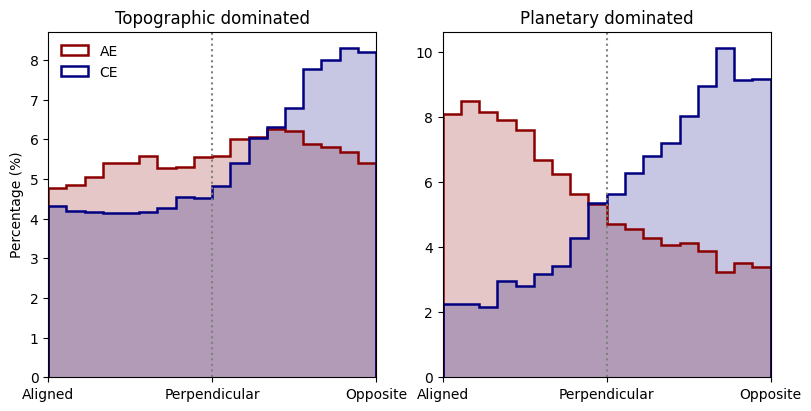

In [5]:
df_plot = df_eddies.copy()
# df_plot = df_plot[df_plot.TiltDis > 5]

col_filters = [
    ("Topographic dominated", df_plot.topo_plan_ratio > 0),
    ("Planetary dominated", df_plot.topo_plan_ratio < 0),
]

bins = np.arange(0, 180 + 10, 10)

fig, axs = plt.subplots(
    1, 2, figsize=(8, 4),
    sharex=True,
    constrained_layout=True
)

for c, (col_label, mask) in enumerate(col_filters):
    ax = axs[c]
    col = df_plot.loc[mask]

    for cyc, color in [("AE", "darkred"), ("CE", "navy")]:
        vals = col.loc[col.Cyc == cyc, "dtheta_PV_grad"].dropna()

        # Each distribution sums to 100%
        weights = np.ones(len(vals)) * 100 / len(vals)

        ax.hist(
            vals, bins=bins,
            weights=weights,
            histtype="stepfilled",
            alpha=0.22,
            color=color
        )

        ax.hist(
            vals, bins=bins,
            weights=weights,
            histtype="step",
            linewidth=1.8,
            color=color,
            label=cyc if c == 0 else None
        )

    ax.axvline(90, color="0.5", linestyle=":")
    ax.set_xlim(0, 180)
    ax.set_title(col_label)

for ax in axs:
    ax.set_xticks([0, 90, 180])
    ax.set_xticklabels(["Aligned", "Perpendicular", "Opposite"])

axs[0].set_ylabel("Percentage (%)")
axs[0].legend(frameon=False)

plt.show()

## PV-gradient regional rose plot

The same regional rose layout can be used with PV-gradient magnitude and direction.


<Axes: >

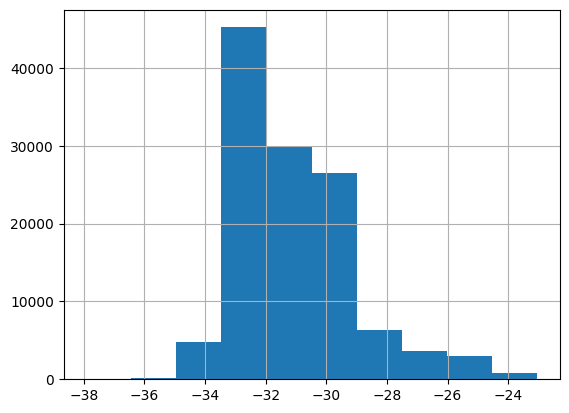

In [6]:
df_eddies['log_PV_grad_mag'].hist()

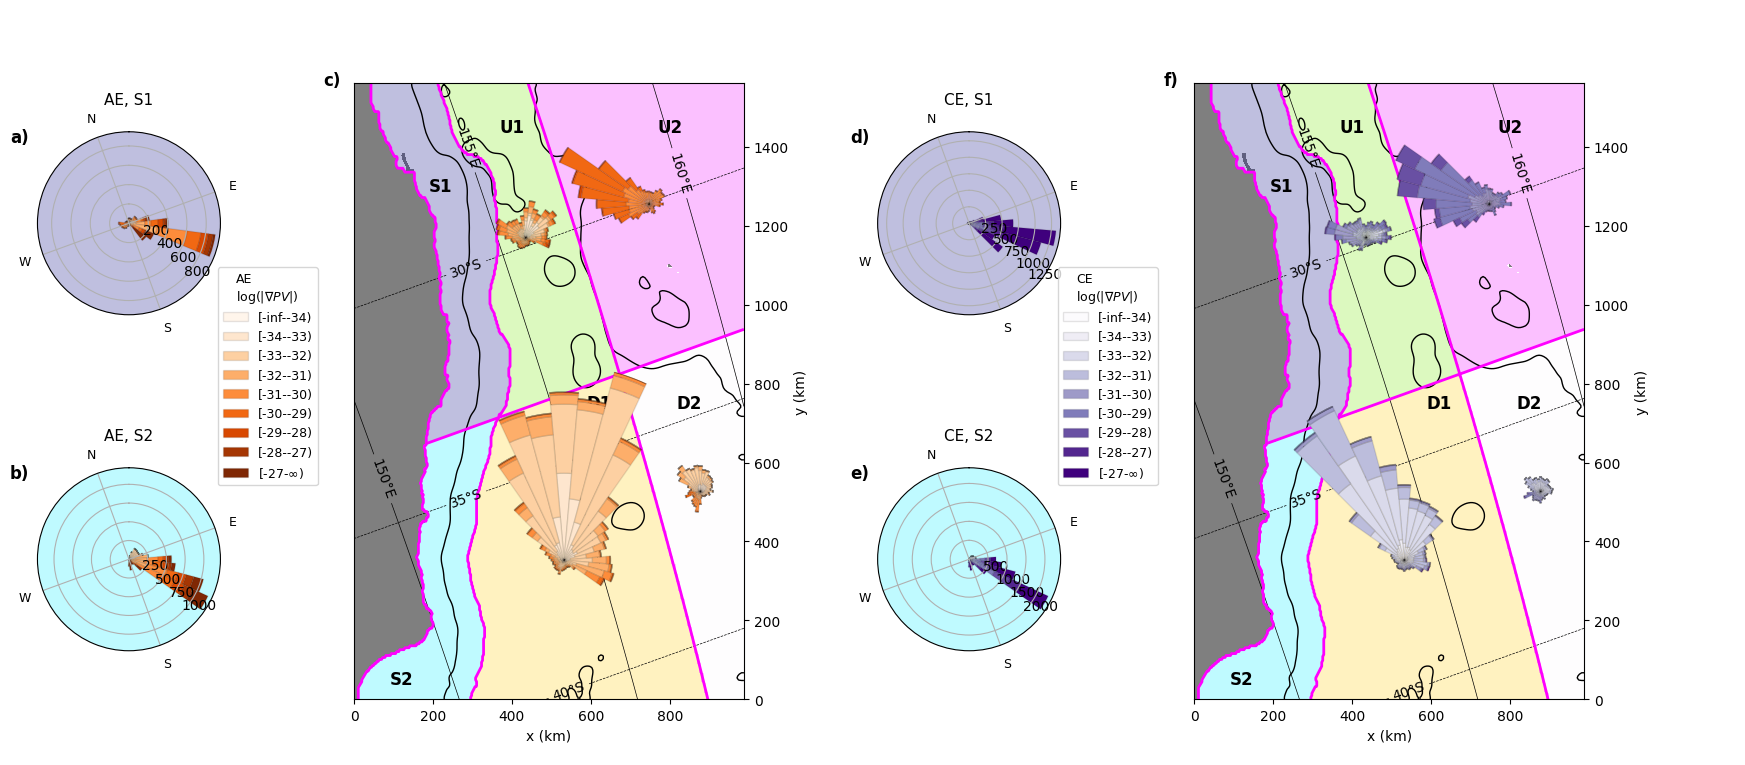

In [7]:
pv_mag_bins = [-np.inf, -34, -33, -32, -31, -30, -29, -28, -27, np.inf]
df_eddies['log_PV_grad_mag'] = np.log(df_eddies['PV_grad_mag'])
fig, rose = tilt.rose_plot(
    df_eddies.dropna(subset=["log_PV_grad_mag", "PV_grad_theta"]),
    grid,
    mag="log_PV_grad_mag",
    theta="PV_grad_theta",
    mag_bins=pv_mag_bins,
    frac=3,
    direction_offset=0,
    shelf_offset=80,
    legend_title=r"log$(|\nabla PV|)$",
    rtick_flag=False,
    cmaps = ['Oranges', 'Purples']
)

#### PV dominance

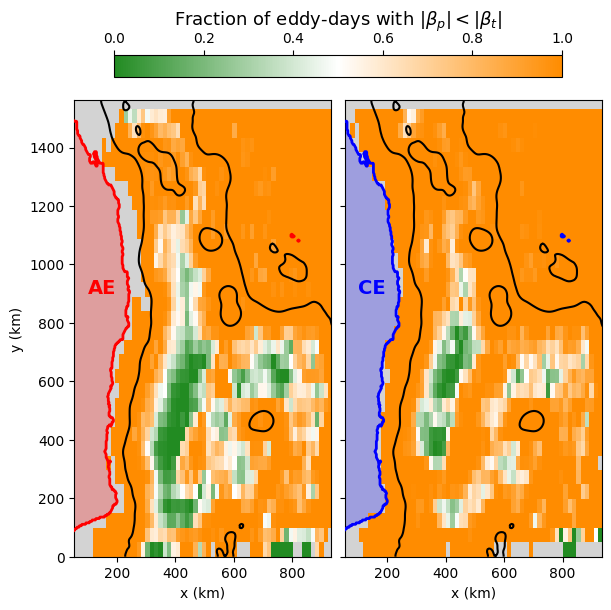

In [8]:
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list(
    "orange_green",
    ["forestgreen", "white", "darkorange"]
)

fig, axs = tilt.plot_pv_dominance(
    df_eddies.dropna(subset=["PV_grad_topo_mag", "PV_grad_plan_mag"]),
    grid,
    clabel=r'Fraction of eddy-days with $|\beta_{p}| < |\beta_{t}|$',
    cmap=cmap
)

# add to the right
axs[3].contourf(grid.X_grid, grid.Y_grid,
                np.where(grid.mask_rho, grid.h/1e3, np.nan), cmap='Greys_r')

# region_mask_grid, bin_grid = tilt.make_region_grids(grid)
# for ax in axs:
#     ax.contour(grid.X_grid, grid.Y_grid, region_mask_grid.astype(float), levels=[0.5],
#                colors="magenta", linewidths=2, linestyles='-')

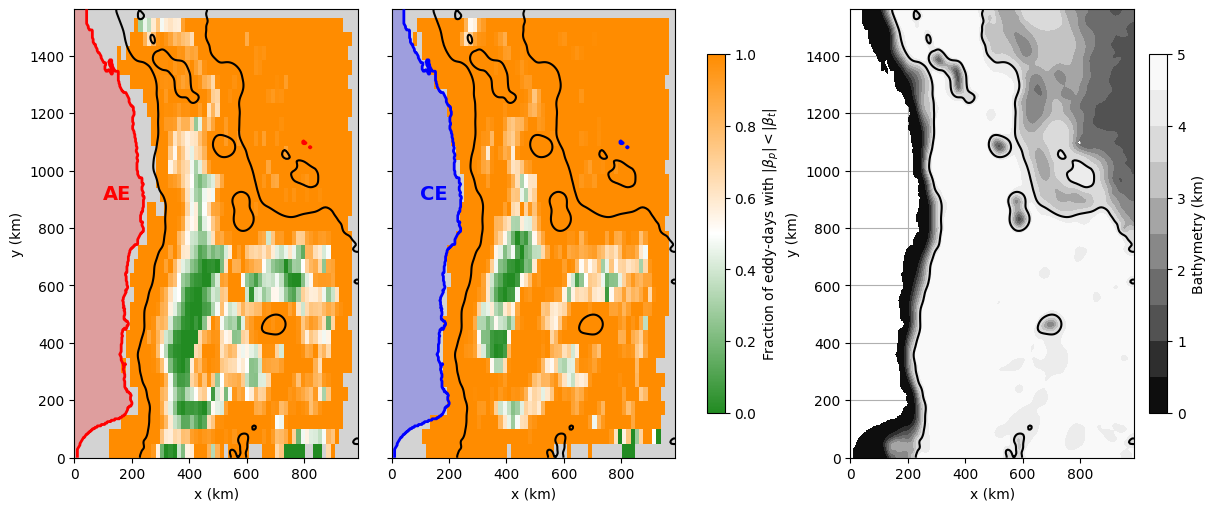

In [45]:
d=df_eddies.dropna(subset=["PV_grad_topo_mag","PV_grad_plan_mag"])
xbins=tilt.bin_edges_fd(d.xc.values,grid.X_grid,rule='fd'); ybins=tilt.bin_edges_fd(d.yc.values,grid.Y_grid,rule='fd')

fig=plt.figure(figsize=(12,5),constrained_layout=True)
gs=fig.add_gridspec(1,3)
ax0=fig.add_subplot(gs[0,0]); ax1=fig.add_subplot(gs[0,1],sharey=ax0); ax2=fig.add_subplot(gs[0,2])
axs=[ax0,ax1,ax2]

for ax,cyc in zip(axs[:2],['AE','CE']):
    dd=d[d.Cyc==cyc].copy(); dd['topo_dom']=dd.PV_grad_topo_mag>dd.PV_grad_plan_mag
    H=tilt.binned_statistic_2d(dd.xc,dd.yc,dd.topo_dom.astype(float),statistic='mean',bins=[xbins,ybins]).statistic.T
    ax.contourf(grid.X_grid,grid.Y_grid,np.where(grid.mask_rho==0,1,np.nan),levels=[.5,1.5],colors=['r' if cyc=='AE' else 'b'],alpha=.25)
    ax.contour(grid.X_grid,grid.Y_grid,grid.mask_rho,levels=[.5],colors='r' if cyc=='AE' else 'b',linewidths=2,zorder=15)
    ax.contour(grid.X_grid,grid.Y_grid,grid.h,levels=[4000],colors='k')
    m=ax.pcolormesh(xbins,ybins,H,cmap=cmap,vmin=0,vmax=1,shading='auto')
    ax.text(100,900,cyc,fontweight='bold',color='r' if cyc=='AE' else 'b',fontsize=14)
    ax.set(xlabel='x (km)',facecolor='lightgrey',
        xlim=(grid.X_grid.min(),grid.X_grid.max()),
        ylim=(grid.Y_grid.min(),grid.Y_grid.max()), aspect='equal');
axs[1].tick_params(axis='y',labelleft=False)

ax0.set_ylabel('y (km)')
cb=fig.colorbar(m,ax=axs[:2],location='right',shrink=.8)
cb.set_label(r'Fraction of eddy-days with $|\beta_p|<|\beta_t|$')

h=np.where(grid.mask_rho,grid.h/1e3,np.nan)
m2=ax2.contourf(grid.X_grid,grid.Y_grid,h,levels=10,cmap='Greys_r', zorder=2)
ax2.contour(grid.X_grid,grid.Y_grid,grid.h,levels=[4000],colors='k', zorder=3)
ax2.set(xlabel='x (km)',ylabel='y (km)',
        xlim=(grid.X_grid.min(),grid.X_grid.max()),
        ylim=(grid.Y_grid.min(),grid.Y_grid.max()), aspect='equal'); ax2.grid(True)
cb2=fig.colorbar(m2,ax=ax2,location='right',shrink=.8)
cb2.set_label('Bathymetry (km)')

In [9]:
df_AE = df_eddies[df_eddies.Cyc == 'AE']
df_CE = df_eddies[df_eddies.Cyc == 'CE']

AE_PV = df_AE.PV_grad_mag.mean()
CE_PV = df_CE.PV_grad_mag.mean()

AE_topo = df_AE.PV_grad_topo_mag.mean()
CE_topo = df_CE.PV_grad_topo_mag.mean()

AE_plan = df_AE.PV_grad_plan_mag.mean()
CE_plan = df_CE.PV_grad_plan_mag.mean()

print('Mean PV-gradient magnitudes')
print('-' * 35)
print(f'Total:        AE = {AE_PV:.3e}    CE = {CE_PV:.3e}    (CE/AE = {CE_PV/AE_PV:.2f})')
print(f'Topographic:  AE = {AE_topo:.3e}    CE = {CE_topo:.3e}    (CE/AE = {CE_topo/AE_topo:.2f})')
print(f'Planetary:    AE = {AE_plan:.3e}    CE = {CE_plan:.3e}    (CE/AE = {CE_plan/AE_plan:.2f})')
print()
print('Topographic / Planetary ratio')
print('-' * 35)
print(f'AE = {AE_topo/AE_plan:.2f}')
print(f'CE = {CE_topo/CE_plan:.2f}')

Mean PV-gradient magnitudes
-----------------------------------
Total:        AE = 1.615e-13    CE = 1.177e-12    (CE/AE = 7.29)
Topographic:  AE = 1.609e-13    CE = 1.177e-12    (CE/AE = 7.32)
Planetary:    AE = 5.447e-15    CE = 8.066e-15    (CE/AE = 1.48)

Topographic / Planetary ratio
-----------------------------------
AE = 29.54
CE = 145.98


In [10]:
# import numpy as np
# import seacofs_tilt_tools as tilt

def background_pv_gradient_grid(grid):
    h = np.asarray(grid.h, dtype=float)
    f = np.asarray(grid.f, dtype=float)
    ocean = np.asarray(grid.mask_rho).astype(bool) & np.isfinite(h) & (h > 0)

    # Physical-coordinate derivatives: metres, not kilometres.
    X = grid.X_grid * 1000.0
    Y = grid.Y_grid * 1000.0
    dh_dx, dh_dy = tilt.phys_grad(h, X, Y, ocean)
    df_dx, df_dy = tilt.phys_grad(f, X, Y, ocean)

    # Rotate from model x/y to east/north, following seacofs_tilt_tools.
    c, s = np.cos(grid.angle), np.sin(grid.angle)
    dh_east  = c * dh_dx - s * dh_dy
    dh_north = s * dh_dx + c * dh_dy
    df_east  = c * df_dx - s * df_dy
    df_north = s * df_dx + c * df_dy

    with np.errstate(divide="ignore", invalid="ignore"):
        pv = f / h

        plan_east  = df_east / h
        plan_north = df_north / h

        topo_east  = -f * dh_east / h**2
        topo_north = -f * dh_north / h**2

        total_east  = plan_east + topo_east
        total_north = plan_north + topo_north

        plan_mag  = np.hypot(plan_east, plan_north)
        topo_mag  = np.hypot(topo_east, topo_north)
        total_mag = np.hypot(total_east, total_north)

        # Same log-ratio convention as your existing analysis:
        # > 0 topographic; < 0 planetary.
        log_topo_plan_ratio = np.log(topo_mag / plan_mag)

    fields = {
        "PV": pv,
        "plan_east": plan_east,
        "plan_north": plan_north,
        "plan_mag": plan_mag,
        "topo_east": topo_east,
        "topo_north": topo_north,
        "topo_mag": topo_mag,
        "total_east": total_east,
        "total_north": total_north,
        "total_mag": total_mag,
        "log_topo_plan_ratio": log_topo_plan_ratio,
    }
    return {
        name: np.where(ocean, values, np.nan)
        for name, values in fields.items()
    }

bg = background_pv_gradient_grid(grid)

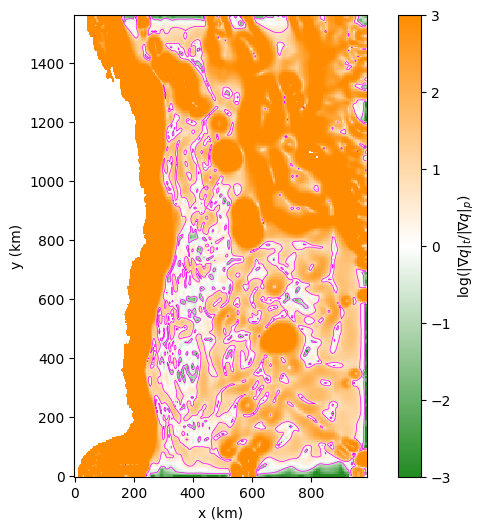

In [11]:
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list(
    "orange_green",
    ["forestgreen", "white", "darkorange"]
)

fig, ax = plt.subplots(figsize=(8, 6))

m = ax.pcolormesh(
    grid.X_grid,
    grid.Y_grid,
    bg["log_topo_plan_ratio"],
    cmap=cmap,
    vmin=-3,
    vmax=3,
    shading="auto",
)

ax.contour(
    grid.X_grid,
    grid.Y_grid,
    bg["log_topo_plan_ratio"],
    levels=[-np.log(2), np.log(2)],
    colors="magenta",
    linewidths=.5,
    linestyles="-"
)

fig.colorbar(
    m, ax=ax,
    label=r"$\log(|\nabla q|_{t}/"
          r"|\nabla q|_{p})$",
)
ax.set(xlabel="x (km)", ylabel="y (km)", aspect="equal")
plt.show()

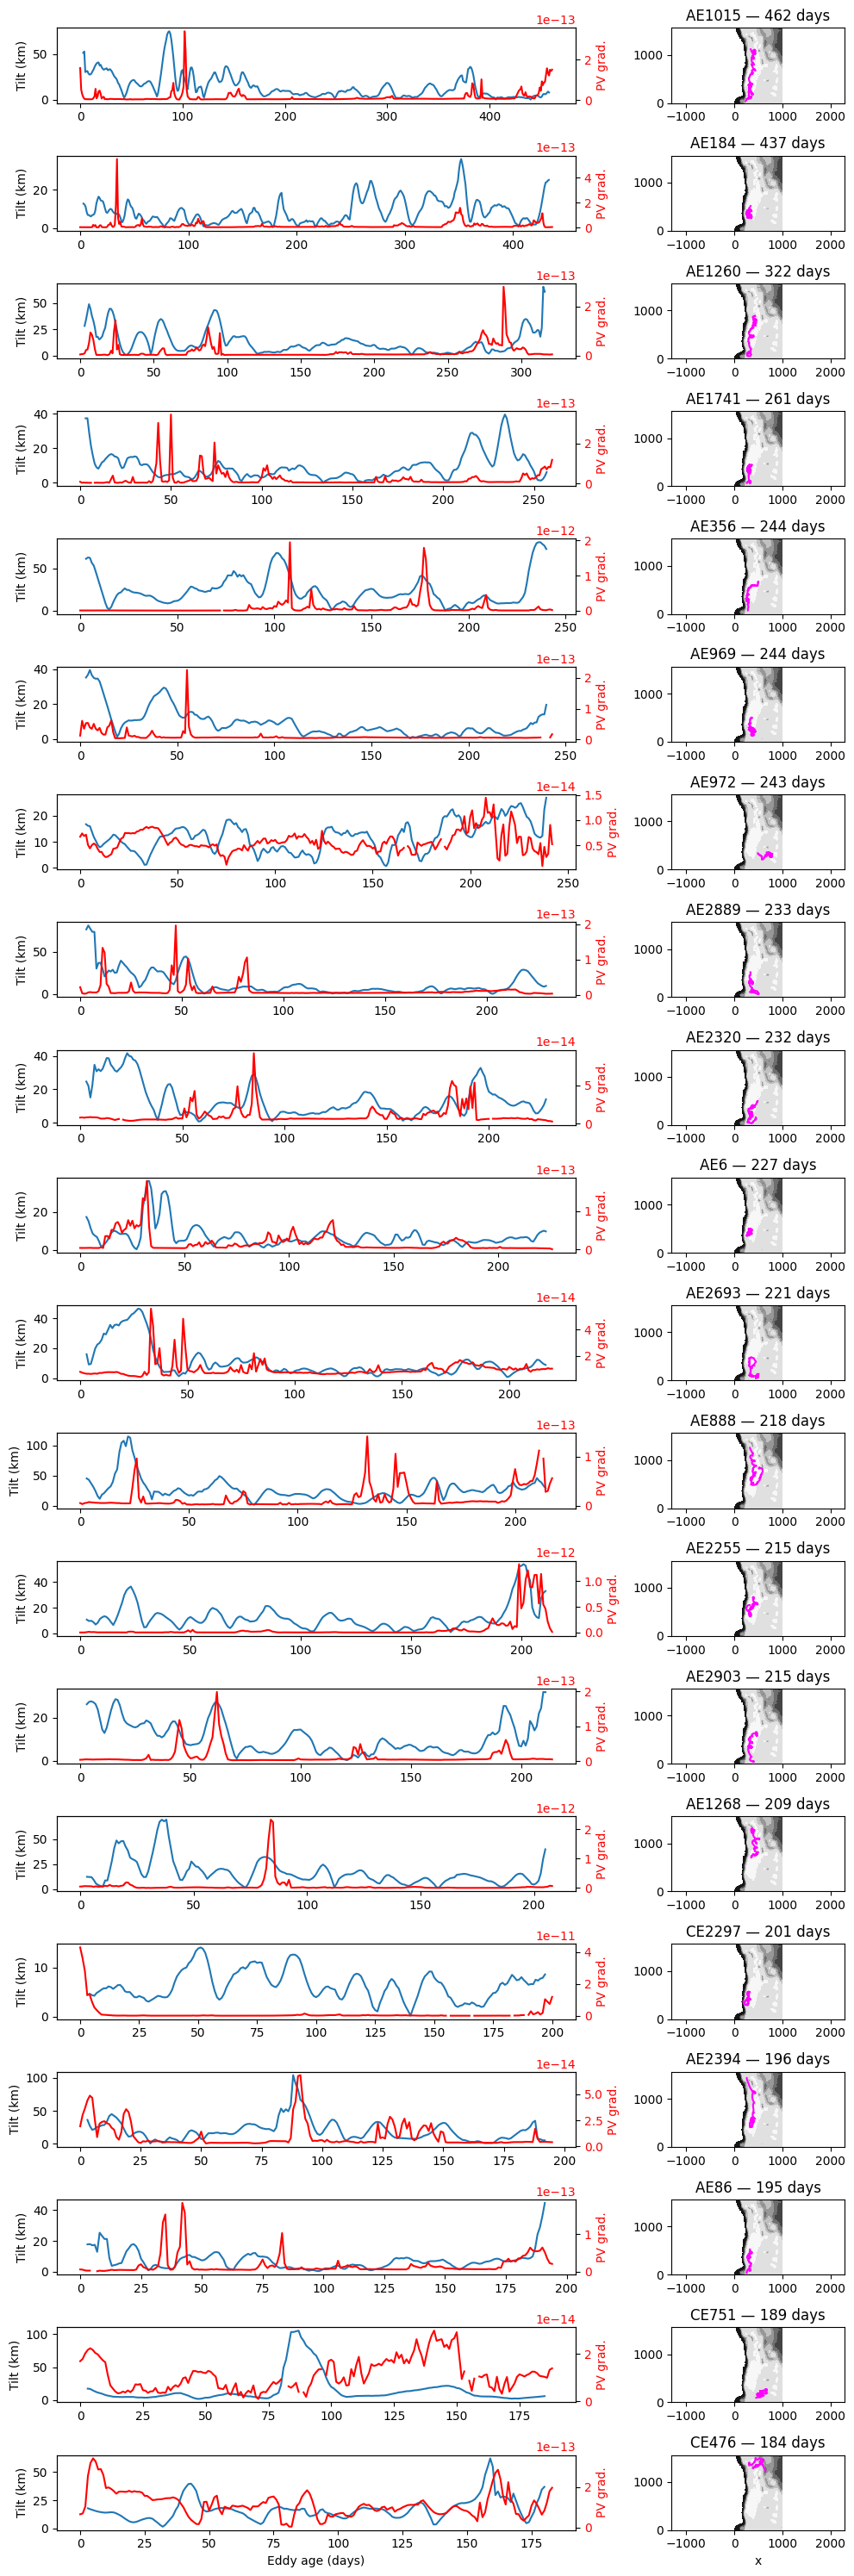

In [12]:
# fig, axs = tilt.tilt_t(df_eddies.copy(), add_field='PV_grad_mag', field_label='PV grad.')
fig, axs = tilt.tilt_t(df_eddies.copy(), grid, add_field='PV_grad_mag', field_label='PV grad.', nlargest=20, figsize=(10,30))

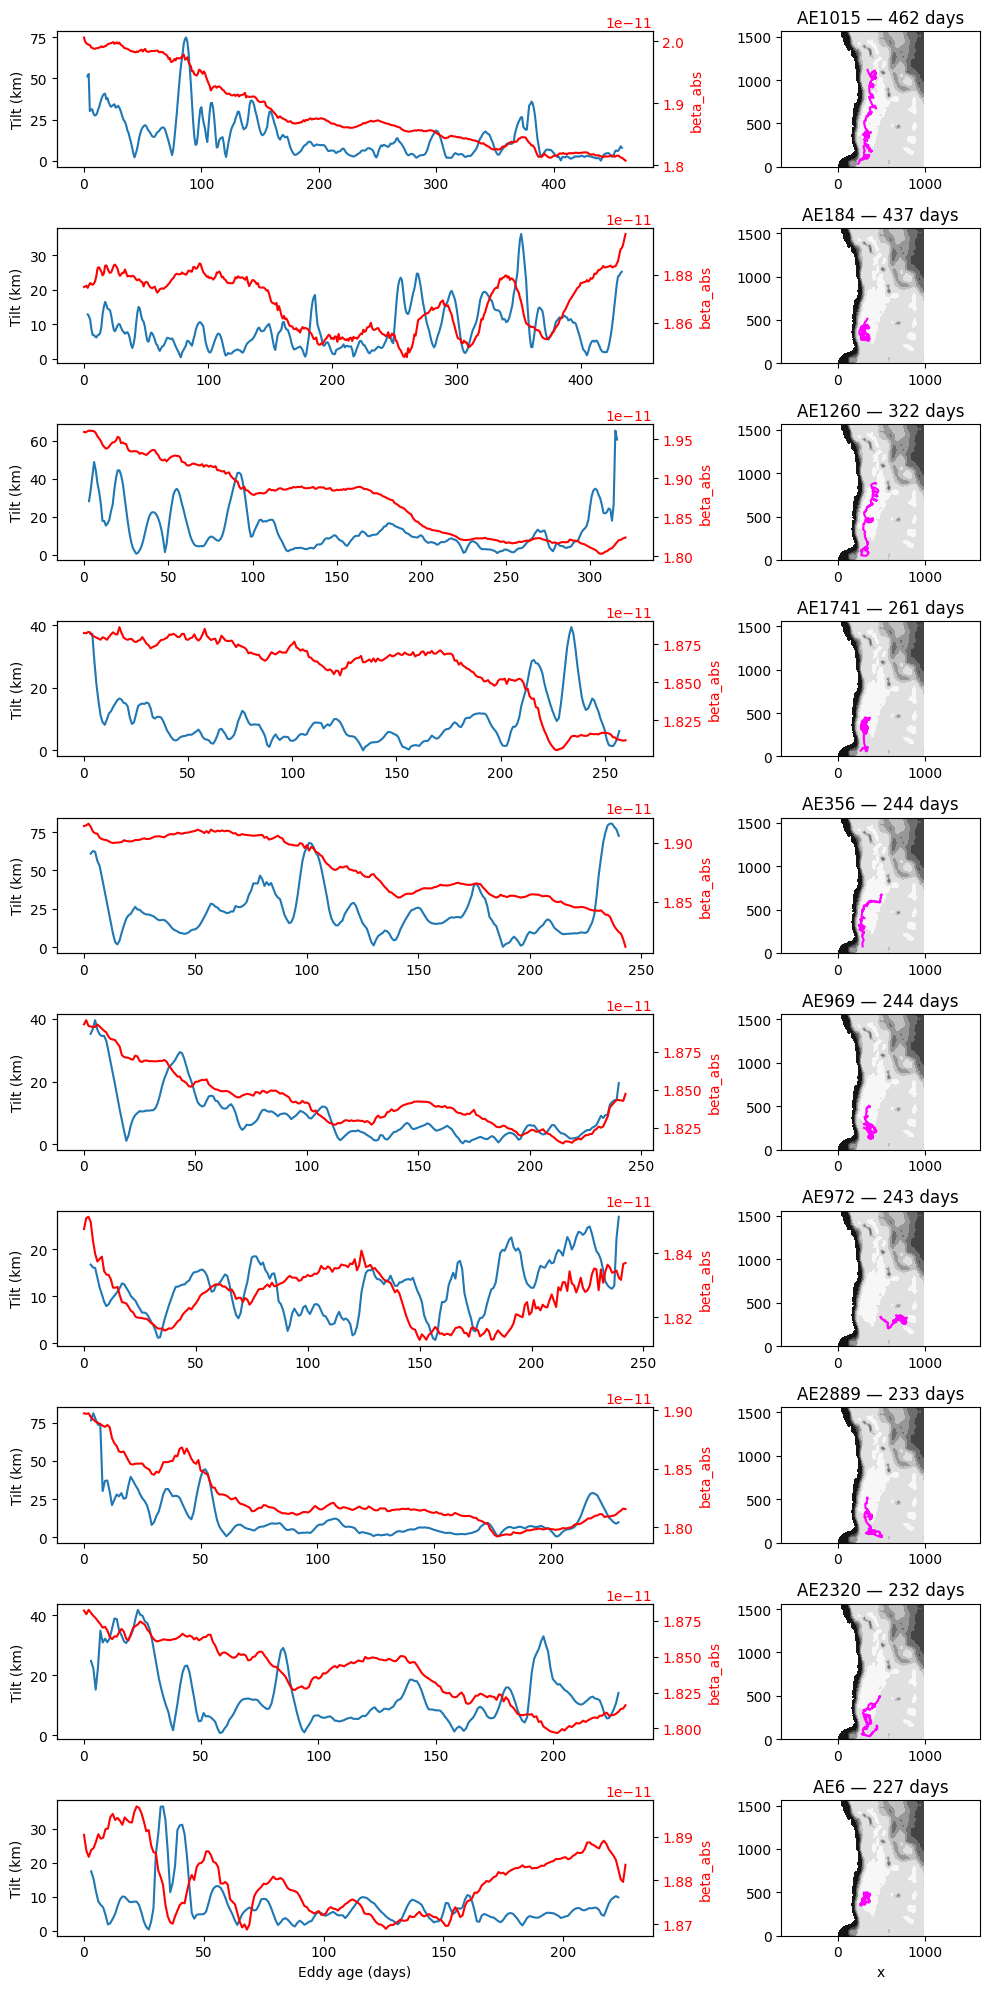

In [13]:
df_eddies['beta_abs'] = df_eddies.beta.abs()
fig, axs = tilt.tilt_t(df_eddies.copy(), grid, add_field='beta_abs', field_label='beta_abs')

In [14]:
# fig, axs = tilt_t(df_eddies.copy(), add_field='f', field_label='f')

In [15]:
df_eddies.columns

Index(['Eddy', 'Day', 'Cyc', 'lon', 'lat', 'ic', 'jc', 'xc', 'yc', 'w',
       'Omega', 'q11', 'q12', 'q22', 'Rc', 'psi0', 'AR', 'R', 'Age', 'Date',
       'fname', 'TiltDis', 'TiltDir', 'Region', 'w_surface',
       'w_selected_depth_m', 'w_profile_n', 'h', 'f', 'beta', 'dhdx', 'dhdy',
       'zeta_mean', 'abs_vort', 'PV', 'PV_footprint_n',
       'PV_weight_effective_n', 'PV_grad_plan_x', 'PV_grad_plan_y',
       'PV_grad_plan_mean_local_mag', 'PV_grad_plan_rms_local_mag',
       'PV_grad_plan_p90_local_mag', 'PV_grad_plan_coherence',
       'PV_grad_topo_x', 'PV_grad_topo_y', 'PV_grad_topo_mean_local_mag',
       'PV_grad_topo_rms_local_mag', 'PV_grad_topo_p90_local_mag',
       'PV_grad_topo_coherence', 'PV_grad_x', 'PV_grad_y',
       'PV_grad_mean_local_mag', 'PV_grad_rms_local_mag',
       'PV_grad_p90_local_mag', 'PV_grad_coherence', 'PV_grad_eddy_x',
       'PV_grad_eddy_y', 'PV_grad_eddy_mean_local_mag',
       'PV_grad_eddy_rms_local_mag', 'PV_grad_eddy_p90_local_mag',
     